# V3.5 — Fine-fuel combustion: the crown flash  **TIER 3 / the canopy burns**

**Claim (pre-registered).** Leaves (the V3.4 canopy fine fuel) ignite and burn out far faster than wood because their surface/volume ratio is huge (the d²-law); under the trunk fire's preheat the canopy ignites in a height-ordered wave and **flashes**, conserving the leaf fuel pool. (`nebula.operators.fine_fuel`, coupled to the V3.2 flame.)

**Why load-bearing.** A 'tree on fire' is most recognizable when the *crown* lights up; without fine-fuel physics the canopy would smoulder like wood. The size-driven burnout split is the mechanism.

**Independent oracle.** `finefuel_ref.py` — the SAV/d²-law scalings (response ∝ d², burnout ∝ dⁿ, σ ∝ 1/d), moisture-dependent ignition, Rothermel spread ∝ σ, crown lag = preheat/spread.

| # | Metric | Threshold |
|---|---|---|
| C1 | burnout scaling: leaf burnout / branch burnout (d²-law) | < 0.01 |
| C2 | ignition time monotone in moisture AND in thickness | both monotone↑ |
| C3 | crown flash: fraction of canopy ignited; crown median ignition time vs base | > 0.9 AND crown later than base |
| C4 | fuel-pool conservation: leaf mass burned vs volatiles released | rel < 1e-9 |
| C5 | determinism: identical ignition-time field on re-run | bit-identical |

In [1]:
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
ROOT = pathlib.Path.cwd().resolve()
while ROOT.name and not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src' / 'implementation'))
sys.path.insert(0, str(ROOT / 'src' / 'verification' / 'oracles'))
from nebula.operators.growth import grow_tree, GrowthParams
from nebula.operators import canopy as cano, fine_fuel as ff
import finefuel_ref as fr
np.seterr(all='ignore')
p = ff.FineFuelParams()
R = {}
tree = grow_tree(seed=7, gp=GrowthParams(dim=3)); can = cano.generate_canopy(tree, cano.CanopyParams(), seed=7)
print(f'canopy {can.n} leaves')

Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 4090" (24 GiB, sm_89, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.14.0


canopy 22764 leaves


In [2]:
# C1 burnout scaling (mechanism vs d²-law oracle)
leaf_bo = p.thickness**2 / p.burn_rate
branch_bo = (2e-2)**2 / p.burn_rate
R['C1'] = leaf_bo/branch_bo
# C2 ignition monotone in moisture & thickness (oracle)
tm = [fr.ignition_time(p.thickness, moisture=m) for m in (0,0.3,0.6,0.9)]
td = [fr.ignition_time(d) for d in (3e-4,1e-3,5e-3,2e-2)]
R['C2_moist'] = bool(np.all(np.diff(tm)>0)); R['C2_thick'] = bool(np.all(np.diff(td)>0))
print(f"C1 leaf/branch burnout {R['C1']:.2e} (<0.01)")
print(f"C2 ignition monotone — moisture {R['C2_moist']}, thickness {R['C2_thick']}")

C1 leaf/branch burnout 2.25e-04 (<0.01)
C2 ignition monotone — moisture True, thickness True


In [3]:
# C3/C4/C5 crown flash
fuel, hist, released = ff.crown_flash(can, p, dt=0.1, n_steps=140, front_speed=0.5)
z = fuel.z; zlo, zhi = z.min(), z.max()
lo_t = float(np.nanmedian(fuel.ignite_t[z < zlo+0.3*(zhi-zlo)]))
hi_t = float(np.nanmedian(fuel.ignite_t[z > zlo+0.7*(zhi-zlo)]))
R['C3_ignfrac'] = float(fuel.ignited.mean()); R['C3_lag'] = hi_t - lo_t
burned = float((fuel.mass0-fuel.mass).sum()); R['C4'] = abs(burned-released)/max(released,1e-30)
fuel2,_,_ = ff.crown_flash(can, p, dt=0.1, n_steps=140, front_speed=0.5)
R['C5'] = bool(np.array_equal(np.nan_to_num(fuel.ignite_t), np.nan_to_num(fuel2.ignite_t)))
print(f"C3 crown flash: {R['C3_ignfrac']*100:.0f}% ignited; base {lo_t:.1f}s -> crown {hi_t:.1f}s (lag {R['C3_lag']:.1f}s)")
print(f"C4 conservation burned {burned:.3f} == released {released:.3f} (rel {R['C4']:.1e}); C5 determinism {R['C5']}")

C3 crown flash: 100% ignited; base 1.8s -> crown 8.2s (lag 6.4s)
C4 conservation burned 15.935 == released 15.935 (rel 1.1e-16); C5 determinism True


saved results/V3_5_crown_flash.png

V3.5 PASS — the canopy flashes: leaves burn out fast and the crown ignites after the trunk.


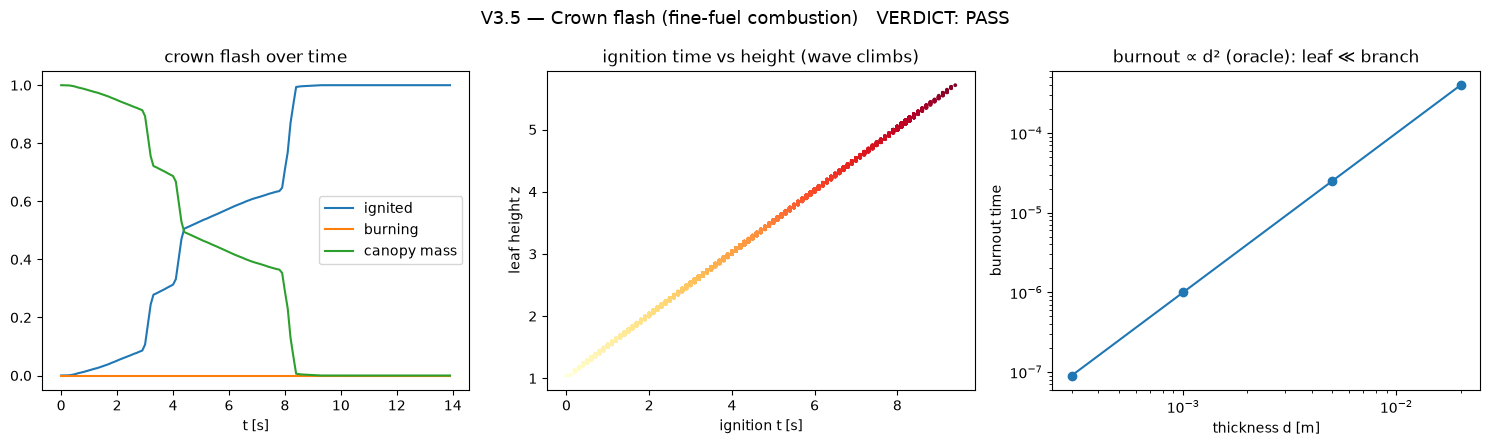

In [4]:
fig = plt.figure(figsize=(15,4.5))
ax0 = fig.add_subplot(131)
ax0.plot(hist['t'], hist['ignited_frac'], label='ignited'); ax0.plot(hist['t'], hist['burning_frac'], label='burning'); ax0.plot(hist['t'], hist['mass_frac'], label='canopy mass')
ax0.set_title('crown flash over time'); ax0.set_xlabel('t [s]'); ax0.legend()
ax1 = fig.add_subplot(132)
ax1.scatter(fuel.ignite_t, z, c=z, cmap='YlOrRd', s=3); ax1.set_title('ignition time vs height (wave climbs)'); ax1.set_xlabel('ignition t [s]'); ax1.set_ylabel('leaf height z')
ax2 = fig.add_subplot(133)
dd = np.array([3e-4,1e-3,5e-3,2e-2]); ax2.loglog(dd, fr.burnout_time(dd),'o-'); ax2.set_title('burnout ∝ d² (oracle): leaf ≪ branch'); ax2.set_xlabel('thickness d [m]'); ax2.set_ylabel('burnout time')
C1=R['C1']<0.01; C2=R['C2_moist'] and R['C2_thick']; C3=R['C3_ignfrac']>0.9 and R['C3_lag']>0; C4=R['C4']<1e-9; C5=R['C5']
allpass=C1 and C2 and C3 and C4 and C5
fig.suptitle(f'V3.5 — Crown flash (fine-fuel combustion)   VERDICT: {"PASS" if allpass else "FAIL"}', fontsize=13)
fig.tight_layout(); fig.savefig('results/V3_5_crown_flash.png', dpi=110, bbox_inches='tight')
print('saved results/V3_5_crown_flash.png')
assert allpass, 'V3.5 criteria not all met'
print('\nV3.5 PASS — the canopy flashes: leaves burn out fast and the crown ignites after the trunk.')